In [1]:
!pip install torchinfo

**Important imports and Updates**

In [2]:
import os
import re
import cv2
import time
import glob
import random
import shutil
import platform
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict
from tabulate import tabulate
from tqdm import tqdm, notebook
from PIL import Image, ImageOps
import PIL
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
from torchvision import transforms, datasets, models
from torchvision.datasets import ImageFolder
from torchvision.transforms import (
    ColorJitter, RandomRotation, RandomResizedCrop
)
from torchvision.transforms.functional import gaussian_blur

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from torchinfo import summary


**This section checks the current Kaggle runtime environment.It collects and displays:CPU model using the platform libraryTotal RAM (in GB) using psutilGPU name via the nvidia-smi command (if a GPU is available)**


In [3]:
import subprocess

cpu_info = platform.processor() or platform.uname().processor or platform.uname().machine

ram_info = psutil.virtual_memory()
total_ram_gb = ram_info.total / (1024 ** 3)

try:
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
    else:
        res = subprocess.run(
            ["nvidia-smi", "--query-gpu=gpu_name", "--format=csv,noheader"],
            capture_output=True, text=True
        )
        gpu_name = res.stdout.strip().splitlines()[0] if res.returncode == 0 and res.stdout.strip() else "No GPU available"
except Exception:
    gpu_name = "No GPU available"

print("CPU:", cpu_info)
print("Total RAM (GB):", round(total_ram_gb, 2))
print("GPU:", gpu_name)


CPU: x86_64
Total RAM (GB): 31.35
GPU: Tesla P100-PCIE-16GB



**To ensure consistent and repeatable results across different runs, a fixed random seed is set here.This controls the randomness in:PyTorch CPU and GPU operations (torch.manual_seed, torch.cuda.manual_seed)NumPy and Python’s built-in random moduleUsing the same seed guarantees that data shuffling, weight initialization, and other random processes produce the same outputs each time the notebook is executed.**


In [4]:
seed = 1

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True, warn_only=True)



**This code organizes PM25Vision images by air-quality labels.It reads metadata.csv, maps PM2.5 bins to categories (Good, Moderate, Unhealthy, etc.), creates label folders, and copies images accordingly.Finally, it prints summary counts and skipped files — readying the dataset for training.**


In [5]:
import re
import shutil
import pandas as pd
from pathlib import Path


CSV_PATH = Path("/kaggle/input/pm25vision/train/metadata.csv")
IMG_DIR  = Path("/kaggle/input/pm25vision/train/images")
OUT_DIR  = Path("/kaggle/working/dataset")
OUT_DIR.mkdir(parents=True, exist_ok=True)

AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None  

def bin_to_label(bin_val) -> str:
    """
    Accepts '0–50', '0-50', '0 — 50', etc.
    Extracts the LOWER numeric bound and maps to label.
    """
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None
    lo = int(m.group(1))
    return aqi_to_label(lo)


df = pd.read_csv(CSV_PATH)
assert "pm25_bin" in df.columns, f"Expected 'pm25_bin' column but found {df.columns}"

fname_col = "filename" if "filename" in df.columns else ("file" if "file" in df.columns else None)
if fname_col is None:
    raise ValueError(f"No image filename column found. Columns: {list(df.columns)}")

df["fname"] = df[fname_col].astype(str)
df["level"] = df["pm25_bin"].apply(bin_to_label)

df = df.dropna(subset=["level"])

print("Class counts:")
print(df["level"].value_counts(dropna=False))

for _, _, label in AQI_BINS:
    (OUT_DIR / label).mkdir(parents=True, exist_ok=True)

missing = 0
copied  = 0
valid_labels = {b[2] for b in AQI_BINS}

for _, row in df.iterrows():
    src = IMG_DIR / row["fname"]
    if not src.exists():
        missing += 1
        continue

    if row["level"] not in valid_labels:
        continue

    dst = OUT_DIR / row["level"] / src.name
    shutil.copy2(src, dst)
    copied += 1

print(f"✅ Done! Copied: {copied} | Missing files skipped: {missing}")
print(f"Output root: {OUT_DIR}")


Class counts:
level
Good                   1780
Moderate               1780
Unhealthy_Sensitive    1780
Unhealthy              1780
Very_Unhealthy          822
Hazardous               356
Name: count, dtype: int64
✅ Done! Copied: 8298 | Missing files skipped: 0
Output root: /kaggle/working/dataset



**This block organizes the test images into the same labeled structure as the training dataset.It reads metadata.csv, maps PM2.5 bins to air-quality categories, and copies each image into its respective label folder under /kaggle/working/dataset/.Duplicate files are checked and renamed if needed, while missing images are skipped.Finally, it prints a summary of copied, skipped, and renamed files.**


In [6]:
TEST_CSV_PATH = Path("/kaggle/input/pm25vision/test/metadata.csv")
TEST_IMG_DIR  = Path("/kaggle/input/pm25vision/test/images")
OUT_TEST_DIR  = Path("/kaggle/working/dataset")  
OUT_TEST_DIR.mkdir(parents=True, exist_ok=True)

AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str | None:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return None

def bin_to_label(bin_val) -> str | None:
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return None
    lo = int(m.group(1))
    return aqi_to_label(lo)

df_t = pd.read_csv(TEST_CSV_PATH)
assert "pm25_bin" in df_t.columns, f"Expected 'pm25_bin' in TEST CSV, got: {df_t.columns}"

fname_col_t = "filename" if "filename" in df_t.columns else ("file" if "file" in df_t.columns else None)
if fname_col_t is None:
    raise ValueError(f"No image filename column in TEST CSV. Columns: {list(df_t.columns)}")

df_t["fname"] = df_t[fname_col_t].astype(str)
df_t["level"] = df_t["pm25_bin"].apply(bin_to_label)

missing, copied, skipped_same, renamed_dupe = 0, 0, 0, 0
valid_labels = {b[2] for b in AQI_BINS}

for _, r in df_t.iterrows():
    src = TEST_IMG_DIR / r["fname"]
    if not src.exists():
        missing += 1
        continue

    if r["level"] not in valid_labels:
        continue

    dest_dir = OUT_TEST_DIR / r["level"]
    dest_dir.mkdir(parents=True, exist_ok=True)

    dst = dest_dir / src.name
    if dst.exists():
        if os.path.getsize(dst) == os.path.getsize(src):
            skipped_same += 1
            continue
        dst = dest_dir / f"test__{src.name}"
        renamed_dupe += 1

    shutil.copy2(src, dst)
    copied += 1

print("✅ TEST copy complete (kept separate).")
print(f"Copied: {copied} | Missing files: {missing} | Skipped exact-duplicates: {skipped_same} | Renamed (name clash): {renamed_dupe}")
print(f"Merged into: {OUT_TEST_DIR}")


✅ TEST copy complete (kept separate).
Copied: 2905 | Missing files: 0 | Skipped exact-duplicates: 16 | Renamed (name clash): 0
Merged into: /kaggle/working/dataset



**This code counts the number of images in each air-quality class under /kaggle/working/dataset/.It prints per-class image totals and the overall dataset size — useful for confirming that all files were organized correctly.**


In [7]:
from pathlib import Path
import shutil

OUT_DIR = Path("/kaggle/working/dataset")


unknown_dir = OUT_DIR / "Unknown"
if unknown_dir.exists() and unknown_dir.is_dir():
    shutil.rmtree(unknown_dir)


class_counts = {}
for sub in OUT_DIR.iterdir():
    if sub.is_dir():
        class_counts[sub.name] = len(list(sub.glob("*")))

print(" Image count per class:\n")

for k, v in sorted(class_counts.items()):
    print(f"{k:20s}: {v}")

print("\nTotal images:", sum(class_counts.values()))

 Image count per class:

Good                : 2408
Hazardous           : 481
Moderate            : 2407
Unhealthy           : 2407
Unhealthy_Sensitive : 2393
Very_Unhealthy      : 1007

Total images: 11103



**This code scans the organized dataset under /kaggle/working/dataset/ and builds a DataFrame listing each image path and its label.It filters valid image formats (.jpg, .jpeg, .png), counts total samples per class, and defines a helper function to load images as RGB arrays.Useful for quick checks, visualization, or later data-loader creation.**


In [8]:
from pathlib import Path
from PIL import Image

BASE_DIR = Path("/kaggle/working/dataset")  
assert BASE_DIR.exists(), BASE_DIR

rows = []
for label_dir in sorted([p for p in BASE_DIR.iterdir() if p.is_dir()]):
    label = label_dir.name
    for p in label_dir.glob("*"):
        if p.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        rows.append({"path": str(p), "label": label})

df = pd.DataFrame(rows)
print("Total images indexed:", len(df))
print("Class balance:\n", df["label"].value_counts())

def load_rgb(path):
    with Image.open(path) as im:
        im = im.convert("RGB")
        return np.array(im)

df.head(20)

Total images indexed: 11103
Class balance:
 label
Good                   2408
Moderate               2407
Unhealthy              2407
Unhealthy_Sensitive    2393
Very_Unhealthy         1007
Hazardous               481
Name: count, dtype: int64


,path,label
0,/kaggle/working/dataset/Good/152580630169945.jpg,Good
1,/kaggle/working/dataset/Good/186183813386458.jpg,Good
2,/kaggle/working/dataset/Good/174395824598705.jpg,Good
3,/kaggle/working/dataset/Good/1278124733106821.jpg,Good
4,/kaggle/working/dataset/Good/306999304330366.jpg,Good
5,/kaggle/working/dataset/Good/906680818149870.jpg,Good
6,/kaggle/working/dataset/Good/1223590698094706.jpg,Good
7,/kaggle/working/dataset/Good/3066347993601180.jpg,Good
8,/kaggle/working/dataset/Good/193635069258032.jpg,Good
9,/kaggle/working/dataset/Good/302788404565338.jpg,Good



**This code visualizes the number of images in each air-quality category using a Seaborn bar chart.It helps verify dataset balance and ensure all classes are properly represented before training.**


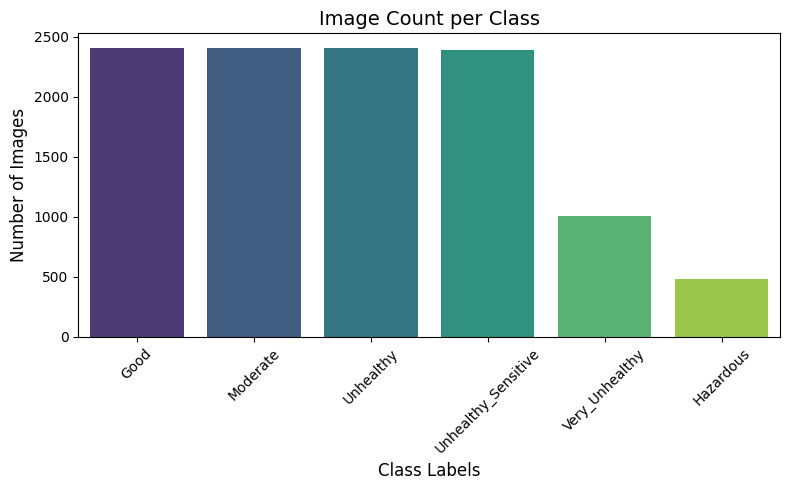

In [9]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df["label"].value_counts().index,
            y=df["label"].value_counts().values,
            palette="viridis")
plt.title("Image Count per Class", fontsize=14)
plt.xlabel("Class Labels", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**This code displays a small gallery showing two random sample images from each air-quality class.It helps visually verify the dataset and observe differences across categories such as Good, Moderate, and Unhealthy.Useful for quick quality checks and understanding visual variation before model training.**


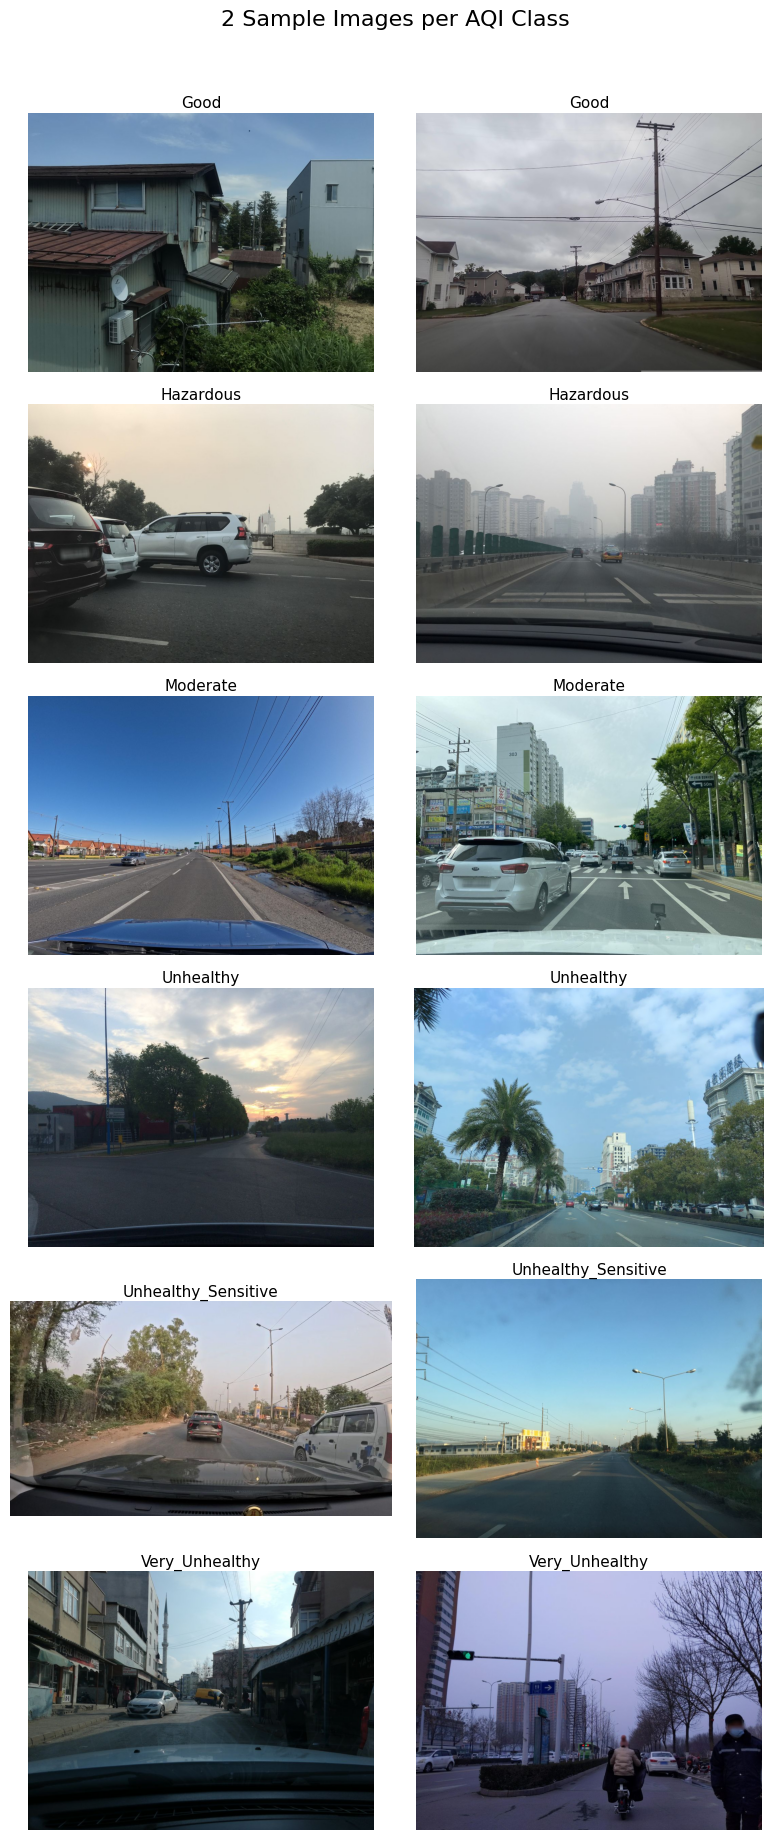

In [10]:
from PIL import Image

classes = sorted(df["label"].unique())

N_PER_CLASS = 2

plt.figure(figsize=(N_PER_CLASS * 4, len(classes) * 3))

for i, lbl in enumerate(classes):
    subset = df[df["label"] == lbl]["path"].tolist()
    sample_paths = random.sample(subset, min(N_PER_CLASS, len(subset)))
    
    for j, path in enumerate(sample_paths):
        idx = i * N_PER_CLASS + j + 1
        plt.subplot(len(classes), N_PER_CLASS, idx)
        
        img = Image.open(path)
        plt.imshow(img)
        plt.axis("off")
        
        plt.title(lbl, fontsize=11, pad=4)

plt.suptitle("2 Sample Images per AQI Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


**This block divides the dataset into train, validation, and test sets for multiple ratios (from 90:10 down to 10:90).Each split is stratified by class labels to keep class balance and uses a fixed random seed (42) for reproducibility.From the training portion, 10% is further used as validation.All splits are saved in dictionaries (SPLITS, FIXED_IDX) and a summary table shows image counts for every ratio**


In [11]:
from sklearn.model_selection import train_test_split
import pandas as pd
from pathlib import Path
import numpy as np
import os


OUT_DIR = Path("/kaggle/working/dataset")

rows = []
for class_dir in sorted([p for p in OUT_DIR.iterdir() if p.is_dir()]):
    label = class_dir.name
    for img_path in class_dir.glob("*"):
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        rows.append({"path": str(img_path), "label": label})

df = pd.DataFrame(rows)
print(f"✅ Found total {len(df)} images across {df['label'].nunique()} classes.")

RATIOS = [(90,10),(80,20),(70,30),(60,40),(50,50),(40,60),(30,70),(20,80),(10,90)]
RANDOM_STATE = 42


SPLITS = {}  
FIXED_IDX = {} 
all_idx = np.arange(len(df))
labels_all = df["label"].values


for tr, te in RATIOS:
    test_size = te / 100.0

    train_pool_idx, test_idx = train_test_split(
        all_idx,
        test_size=test_size,
        stratify=labels_all,
        random_state=RANDOM_STATE
    )
    FIXED_IDX[(tr, te)] = {
        "train_pool_idx": train_pool_idx,
        "test_idx": test_idx
    }

    train_pool_df = df.iloc[train_pool_idx].reset_index(drop=True)
    tr_local_idx, va_local_idx = train_test_split(
        np.arange(len(train_pool_df)),
        test_size=0.10,
        stratify=train_pool_df["label"].values,
        random_state=RANDOM_STATE
    )

    train_idx = train_pool_idx[tr_local_idx]
    valid_idx = train_pool_idx[va_local_idx]

    train_df = df.iloc[train_idx].reset_index(drop=True)
    valid_df = df.iloc[valid_idx].reset_index(drop=True)
    test_df  = df.iloc[test_idx].reset_index(drop=True)

    SPLITS[(tr, te)] = {
        "train_df": train_df,
        "valid_df": valid_df,
        "test_df":  test_df
    }


print("\n=== Split Summary (counts) ===")
for tr, te in RATIOS:
    s = SPLITS[(tr, te)]
    print(f"{tr}:{te} -> train={len(s['train_df'])}, val={len(s['valid_df'])}, test={len(s['test_df'])}")
print("-------------------------------------------")
print("Total images in dataset: ", len(df))

✅ Found total 11103 images across 6 classes.

=== Split Summary (counts) ===
90:10 -> train=8992, val=1000, test=1111
80:20 -> train=7993, val=889, test=2221
70:30 -> train=6994, val=778, test=3331
60:40 -> train=5994, val=667, test=4442
50:50 -> train=4995, val=556, test=5552
40:60 -> train=3996, val=445, test=6662
30:70 -> train=2997, val=333, test=7773
20:80 -> train=1998, val=222, test=8883
10:90 -> train=999, val=111, test=9993
-------------------------------------------
Total images in dataset:  11103



**This block prints class-wise image counts for train, validation, and test sets at each ratio using the tabulate library.It helps verify that all splits remain balanced across classes and that no samples are missing.**


In [12]:
from tabulate import tabulate

for tr, te in RATIOS:
    s = SPLITS[(tr, te)]
    train_df = s["train_df"]; valid_df = s["valid_df"]; test_df = s["test_df"]

    class_counts_train = train_df['label'].value_counts()
    class_counts_valid = valid_df['label'].value_counts()
    class_counts_test  = test_df['label'].value_counts()

    train_table_data = [[class_name, count] for class_name, count in class_counts_train.items()]
    valid_table_data = [[class_name, count] for class_name, count in class_counts_valid.items()]
    test_table_data  = [[class_name, count]  for class_name, count  in class_counts_test.items()]

    print(f"\n=== {tr}:{te} Split ===")
    print("\n Train Dataset")
    print(tabulate(train_table_data, headers=["Class", "Count"], tablefmt="github"))

    print("\n Validation Dataset")
    print(tabulate(valid_table_data, headers=["Class", "Count"], tablefmt="github"))

    print("\n Test Dataset")
    print(tabulate(test_table_data, headers=["Class", "Count"], tablefmt="github"))


=== 90:10 Split ===

 Train Dataset
| Class               |   Count |
|---------------------|---------|
| Good                |    1950 |
| Unhealthy           |    1949 |
| Moderate            |    1949 |
| Unhealthy_Sensitive |    1939 |
| Very_Unhealthy      |     815 |
| Hazardous           |     390 |

 Validation Dataset
| Class               |   Count |
|---------------------|---------|
| Good                |     217 |
| Moderate            |     217 |
| Unhealthy           |     217 |
| Unhealthy_Sensitive |     215 |
| Very_Unhealthy      |      91 |
| Hazardous           |      43 |

 Test Dataset
| Class               |   Count |
|---------------------|---------|
| Good                |     241 |
| Unhealthy           |     241 |
| Moderate            |     241 |
| Unhealthy_Sensitive |     239 |
| Very_Unhealthy      |     101 |
| Hazardous           |      48 |

=== 80:20 Split ===

 Train Dataset
| Class               |   Count |
|---------------------|---------|
| Good

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

**Creates a base folder /kaggle/working/task2_MobileNet to store model checkpoints, logs, and outputs. Ensures the directory exists before training begins.**

In [14]:
save_root_base = "/kaggle/working/task2_mobilenetv3"
os.makedirs(save_root_base, exist_ok=True)


**Defines a reusable ImageDataset class for loading PM25Vision images in PyTorch.It:Reads image paths and labels from a DataFrame.Converts labels into numeric indices via a mapping dictionary.Loads each image in RGB format and applies given normalization transforms.Optionally returns labels (is_lb=True) for training or just images for inference**

In [15]:
import PIL.Image
from torch.utils.data import Dataset

class ImageDataset(Dataset):
    def __init__(self, dataframe, normalize, is_lb=True, label_map=None):
        """
        Args:
            dataframe : pd.DataFrame with 'path' and (if labeled) 'label' columns
            normalize : torchvision.transforms to apply to images
            is_lb     : bool, True if labels should be returned
            label_map : optional dict {class_name: index} to ensure consistent mapping across splits
        """
        self.dataframe = dataframe.reset_index(drop=True)
        self.normalize = normalize
        self.is_lb = is_lb

        if self.is_lb:
            if label_map is None:
                unique_labels = sorted(self.dataframe['label'].unique())
                self.label_map = {label: idx for idx, label in enumerate(unique_labels)}
            else:
                self.label_map = dict(label_map)
        else:
            self.label_map = None

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        img_path = self.dataframe.iloc[index]['path']
        with PIL.Image.open(img_path) as im:
            image = im.convert("RGB")

        image = self.normalize(image) if self.normalize is not None else image

        if self.is_lb:
            label_name = self.dataframe.iloc[index]['label']
            label = self.label_map[label_name]
            return image, label
        else:
            
            return image, img_path



**Implemented data transformation and DataLoader pipeline. Added ImageNet-based normalization using Resize → ToTensor → Normalize. Created separate DataLoaders for training, validation, and testing datasets. Used batch sizes 32 for training and 8 for validation/testing. Ensures consistent preprocessing and efficient batching for MobileNet_V3 workflow.**



In [16]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

train_batch = 32
val_batch = 8

def data_transform(train_df, valid_df, test_df):
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std  = [0.229, 0.224, 0.225]

    normalize = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    all_classes = sorted(pd.concat([train_df["label"], valid_df["label"], test_df["label"]]).unique())
    label_map = {cls: i for i, cls in enumerate(all_classes)}

    train_dataset = ImageDataset(
        train_df,
        normalize,
        is_lb=True,
        label_map=label_map
    )

    valid_dataset = ImageDataset(
        valid_df,
        normalize,
        is_lb=True,
        label_map=label_map
    )

    test_dataset = ImageDataset(
        test_df,
        normalize,
        is_lb=True,
        label_map=label_map
    )

    pin = torch.cuda.is_available()
    dataloader_train_dataset = DataLoader(
        train_dataset, batch_size=train_batch, shuffle=True, num_workers=2,
        pin_memory=pin, persistent_workers=True
    )
    dataloader_valid_dataset = DataLoader(
        valid_dataset, batch_size=val_batch, shuffle=False, num_workers=2,
        pin_memory=pin, persistent_workers=True
    )
    dataloader_test_dataset = DataLoader(
        test_dataset, batch_size=val_batch, shuffle=False, num_workers=2,
        pin_memory=pin, persistent_workers=True
    )

    return dataloader_train_dataset, dataloader_valid_dataset, dataloader_test_dataset



**Added model complexity analysis for MobileNetV3-Large.Loaded pretrained MobileNetV3-Large and replaced the final classifier layer based on total classes.Integrated THOP library to compute MACs, FLOPs, and parameter count.Automatically installs THOP if missing for compatibility.Prints formatted summary showing computational cost (GMACs / GFLOPs / M-params) at 224×224 input resolution.**



In [17]:
total_class = len(df['label'].unique())   
learning_rate = 0.0001

try:
    from torchvision.models import MobileNet_V3_Large_Weights
    model = models.mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1)
except Exception:
    model = models.mobilenet_v3_large(pretrained=True)

num_ftrs = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(num_ftrs, total_class)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

summary(model, input_size=(train_batch, 3, 224, 224))

try:
    from thop import profile
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "thop"])
    from thop import profile

model.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(device)
    macs, params = profile(model, inputs=(dummy,), verbose=False)

gmacs  = macs / 1e9
gflops = (2 * macs) / 1e9
mparams = params / 1e6

print(f"[Complexity @224x224]  MACs: {gmacs:.2f} GMACs  (~{gflops:.2f} GFLOPs)  |  Params: {mparams:.2f} M")


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 193MB/s]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.9 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libcugraph-cu12 25.6.0 requires libraft-cu12==25.6.*, but you have libraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires pylibraft-cu12==25.6.*, but you have pylibraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 25.6.0 requires rmm-cu12==25.6.*, but you have rmm-cu12 25.2.0 which is incompatible.


[Complexity @224x224]  MACs: 0.23 GMACs  (~0.47 GFLOPs)  |  Params: 4.21 M



**Trains MobileNet_V3 for each (train:test) ratio in RATIOS with Adam + CrossEntropy for 50 epochs.train_model(...) shows tqdm progress, tracks train/val loss & accuracy, and saves the best checkpoint (model.pt) on improved val accuracy. Writes per-epoch metrics to training_data.xlsx in each ratio’s checkpoint folder. Prints epoch time, total time, and avg sec/epoch per ratio; aggregates results in RESULTS_ROWS. Finally reports the overall wall-clock time across all ratios.**


In [18]:
start_time_global = time.time()

def train_model(model, criterion, optimizer, dataloader_train_dataset, dataloader_valid_dataset, num_epochs=50, save_path_checkpoints="checkpoints"):
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    os.makedirs(save_path_checkpoints, exist_ok=True)

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        epoch_start_time = time.time()  
        # Training phase
        model.train()

        running_loss = 0.0
        correct_train = 0
        total_train = 0

        progress_bar = tqdm(enumerate(dataloader_train_dataset), total=len(dataloader_train_dataset))
        for i, (inputs, labels) in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            progress_bar.set_description(f"Epoch {epoch+1}/{num_epochs}")
            progress_bar.set_postfix(loss=running_loss / total_train, acc=correct_train / total_train)

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train
        train_loss_history.append(epoch_train_loss)
        train_acc_history.append(epoch_train_acc)
        print('Training Loss: {:.3f} Acc: {:.3f}'.format(epoch_train_loss, epoch_train_acc))

        # Validation phase
        model.eval()
        running_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in dataloader_valid_dataset:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, predicted = torch.max(outputs, 1)
                running_loss += loss.item() * inputs.size(0)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = running_loss / total_val
        epoch_val_acc = correct_val / total_val
        val_loss_history.append(epoch_val_loss)
        val_acc_history.append(epoch_val_acc)

        print('Validation Loss: {:.3f} Acc: {:.3f}'.format(epoch_val_loss, epoch_val_acc))

        epoch_time = time.time() - epoch_start_time
        print(f"Epoch {epoch+1} Time: {epoch_time:.2f} seconds")

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_epoch = epoch + 1
            filepath = f"{save_path_checkpoints}/model.pt"
            checkpoint = {
                "epoch": epoch + 1,
                "model_weight": model.state_dict(),
                "optimizer_state": optimizer.state_dict()
            }
            torch.save(checkpoint, filepath)
            print(f"Best model saved at epoch {best_epoch} with validation accuracy: {best_val_acc:.3f}")

    return train_loss_history, train_acc_history, val_loss_history, val_acc_history

import json
RESULTS_ROWS = []  
for (tr, te) in RATIOS:
    print(f"\n================= Running MobileNetV3-Large for ratio {tr}:{te} =================")
    split = SPLITS[(tr, te)]
    tr_df = split["train_df"]; va_df = split["valid_df"]; te_df = split["test_df"]

    dataloader_train_dataset, dataloader_valid_dataset, dataloader_test_dataset = data_transform(tr_df, va_df, te_df)

    # ---- MobileNetV3-Large (pretrained) ----
    try:
        from torchvision.models import MobileNet_V3_Large_Weights
        model_ratio = models.mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1)
    except Exception:
        model_ratio = models.mobilenet_v3_large(pretrained=True)

    num_ftrs = model_ratio.classifier[-1].in_features
    model_ratio.classifier[-1] = nn.Linear(num_ftrs, len(df['label'].unique()))
    model_ratio = model_ratio.to(device)

    optimizer_ratio = optim.Adam(model_ratio.parameters(), lr=learning_rate)
    criterion_ratio = nn.CrossEntropyLoss()

    save_path_checkpoints = os.path.join(save_root_base, f"{tr}_{te}")
    os.makedirs(save_path_checkpoints, exist_ok=True)

    start_time = time.time()

    train_loss_history, train_acc_history, val_loss_history, val_acc_history = train_model(
        model_ratio, criterion_ratio, optimizer_ratio,
        dataloader_train_dataset, dataloader_valid_dataset,
        num_epochs=50, save_path_checkpoints=save_path_checkpoints
    )
    end_time = time.time()
    training_time = end_time - start_time
    print(f"Training Time [{tr}:{te}]: {training_time:.2f} seconds ---> {training_time/60:.2f} minutes")
    print(f"Average Per-Epoch Time [{tr}:{te}]: {training_time/50:.2f} seconds/epoch")

    data_hist = {
        'Epoch': list(range(1, len(train_loss_history) + 1)),
        'Train Loss': train_loss_history,
        'Train Accuracy': train_acc_history,
        'Validation Loss': val_loss_history,
        'Validation Accuracy': val_acc_history
    }
    history = pd.DataFrame(data_hist)
    hist_path = os.path.join(save_path_checkpoints, 'training_data.xlsx')
    history.to_excel(hist_path, index=False)

    RESULTS_ROWS.append({
        "ratio": f"{tr}:{te}",
        "checkpoint_dir": save_path_checkpoints,
        "history_path": hist_path
    })

end_time_global = time.time()
print(f"\n=== All ratios done in {end_time_global - start_time_global:.2f} seconds ===")



================= Running MobileNetV3-Large for ratio 90:10 =================


  0%|          | 0/281 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/autograd/graph.py:823: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:217.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Epoch 1/50: 100%|██████████| 281/281 [01:06<00:00,  4.25it/s, acc=0.433, loss=1.32]

Training Loss: 1.323 Acc: 0.433


Validation Loss: 1.099 Acc: 0.535
Epoch 1 Time: 73.65 seconds
Best model saved at epoch 1 with validation accuracy: 0.535


Epoch 2/50: 100%|██████████| 281/281 [01:06<00:00,  4.26it/s, acc=0.645, loss=0.874]


...

Training Loss: 0.004 Acc: 0.999
Validation Loss: 2.976 Acc: 0.459
Epoch 48 Time: 8.15 seconds


Epoch 49/50: 100%|██████████| 32/32 [00:07<00:00,  4.42it/s, acc=0.996, loss=0.0113]


Training Loss: 0.011 Acc: 0.996
Validation Loss: 2.809 Acc: 0.450
Epoch 49 Time: 8.04 seconds


Epoch 50/50: 100%|██████████| 32/32 [00:07<00:00,  4.37it/s, acc=1, loss=0.00392]


Training Loss: 0.004 Acc: 1.000
Validation Loss: 2.809 Acc: 0.477
Epoch 50 Time: 8.11 seconds
Training Time [10:90]: 423.22 seconds ---> 7.05 minutes
Average Per-Epoch Time [10:90]: 8.46 seconds/epoch

=== All ratios done in 18769.79 seconds ===



**This block plots loss and accuracy curves from each ratio’s training history (training_data.xlsx).It shows side-by-side subplots for train vs validation performance across epochs, saves each plot as curves.png inside the corresponding checkpoint folder, and displays them for review.**


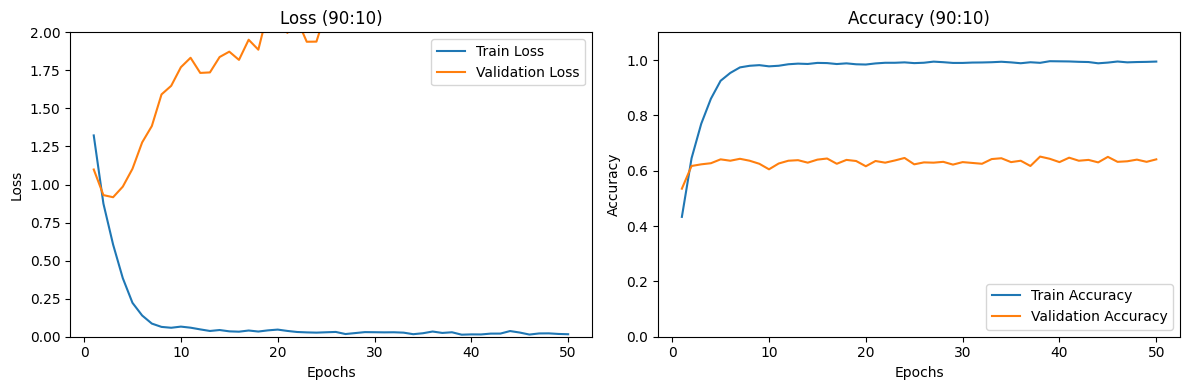

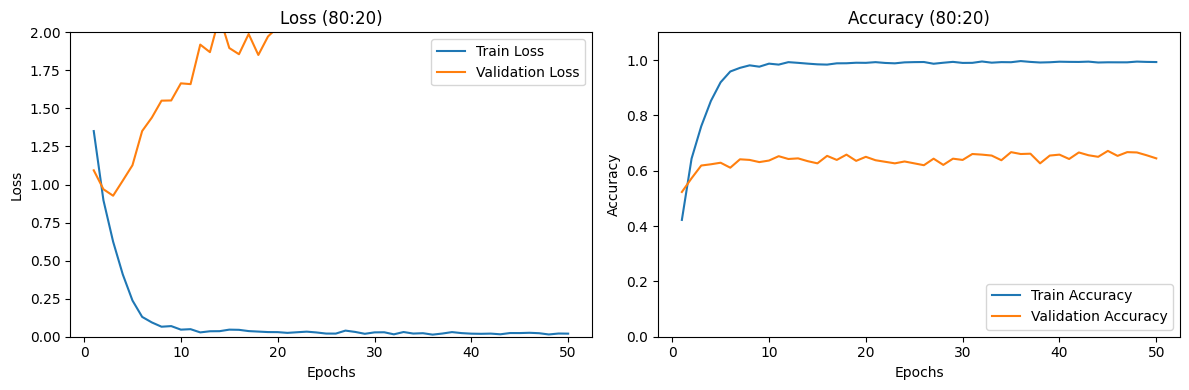

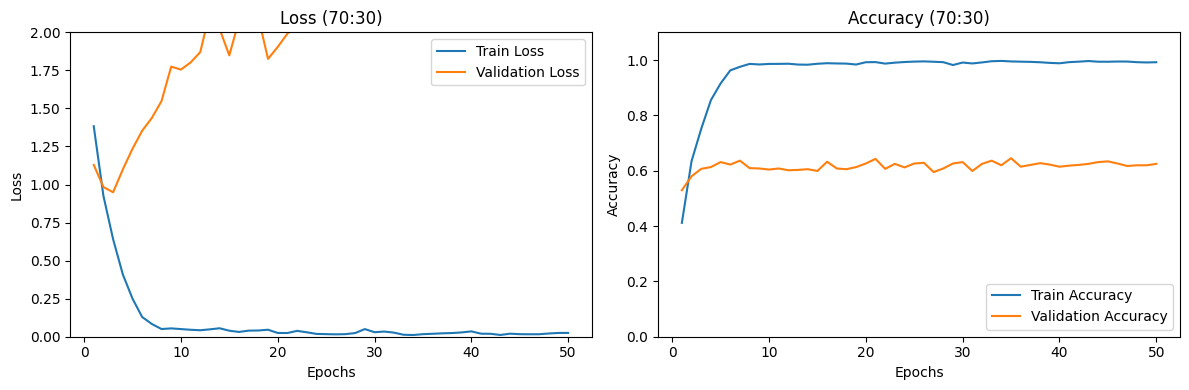

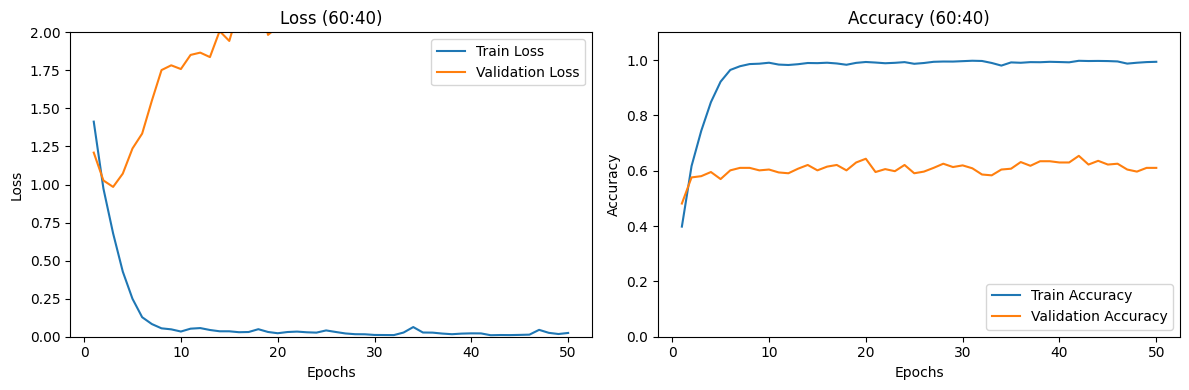

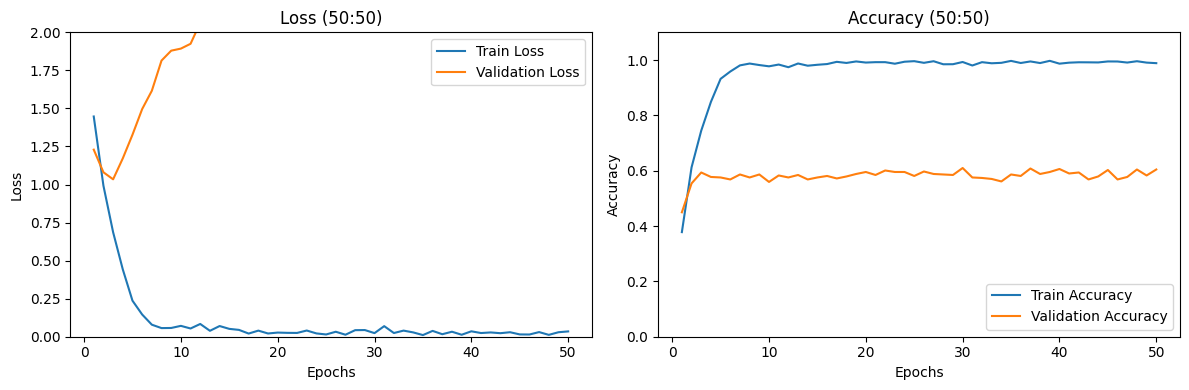

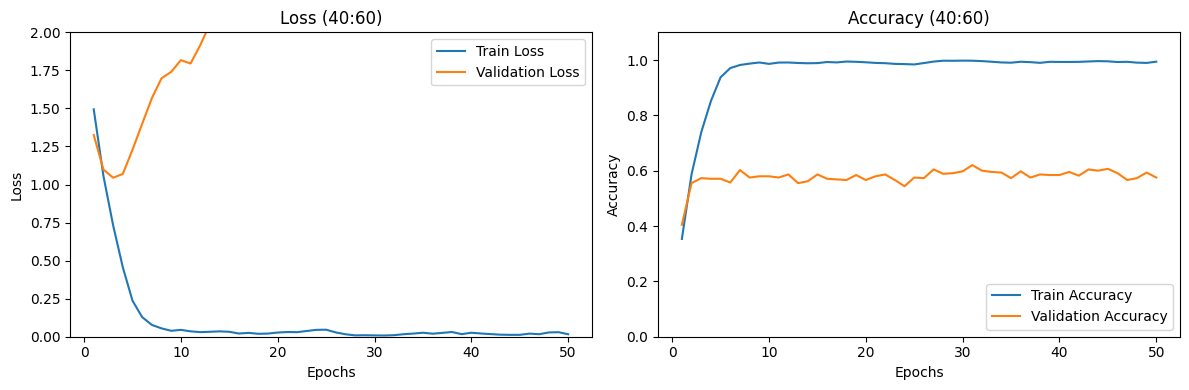

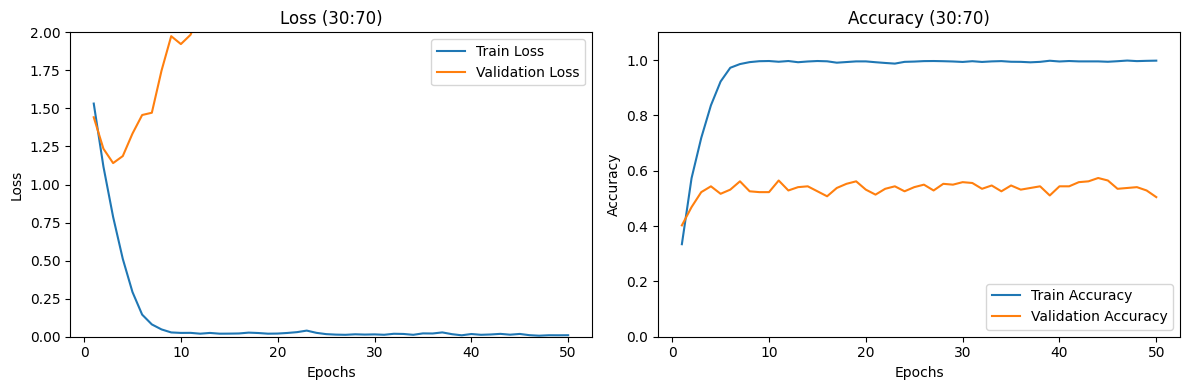

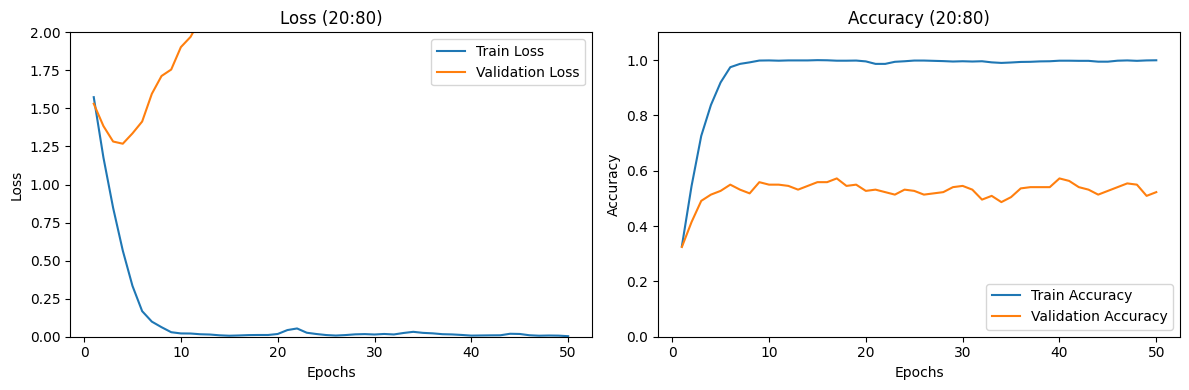

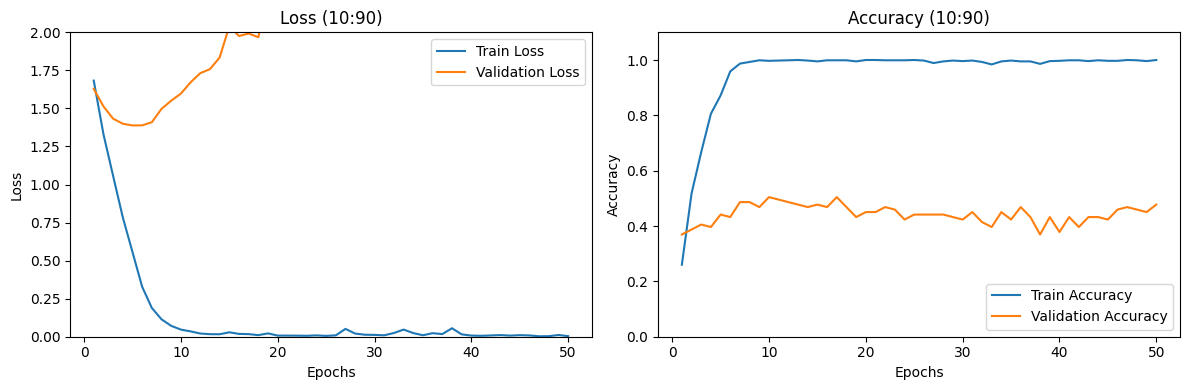

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import os

for (tr, te) in RATIOS:
    save_path_checkpoints = os.path.join("/kaggle/working/task2_mobilenetv3", f"{tr}_{te}")
    hist_xlsx = os.path.join(save_path_checkpoints, 'training_data.xlsx')
    if not os.path.exists(hist_xlsx):
        print(f"[{tr}:{te}] history file missing at {hist_xlsx}")
        continue

    history = pd.read_excel(hist_xlsx)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['Epoch'], history['Train Loss'], label='Train Loss')
    plt.plot(history['Epoch'], history['Validation Loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'Loss ({tr}:{te})')
    plt.legend(loc='upper right')
    plt.ylim(0, 2)

    plt.subplot(1, 2, 2)
    plt.plot(history['Epoch'], history['Train Accuracy'], label='Train Accuracy')
    plt.plot(history['Epoch'], history['Validation Accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy ({tr}:{te})')
    plt.legend(loc='lower right')
    plt.ylim(0, 1.1)

    plt.tight_layout()
    plot_path = os.path.join(save_path_checkpoints, "curves.png")
    plt.savefig(plot_path)
    plt.show()



**Defines evaluate_model() to test a trained model on any dataset.It computes average loss and overall accuracy, and optionally returns predictions, true labels, and softmax probabilities.The model runs in evaluation mode (torch.no_grad()), ensuring no gradient updates during inference.**


In [20]:
import torch
import numpy as np

def evaluate_model(model, criterion, dataloader, return_preds=False):
    """
    Evaluate model on given dataloader.

    Args:
        model: PyTorch model
        criterion: loss function
        dataloader: DataLoader for evaluation
        return_preds: bool, if True returns all predictions and labels (and probs)

    Returns:
        loss: average loss
        accuracy: overall accuracy
        (optional) all_preds, all_labels, all_probs (softmax)
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            if return_preds:
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

    loss = running_loss / total 
    accuracy = correct / total

    if return_preds:
        return loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)
    else:
        return loss, accuracy


**This block reloads the best saved model for each (train:test) ratio and evaluates it on the validation set.It restores model weights, optimizer state, and epoch info from model.pt, rebuilds DataLoaders, and reports validation loss and accuracy for the saved best epoch.**


In [21]:
import os
import torch

for (tr, te) in RATIOS:
    print(f"\n[Validation Eval] Ratio {tr}:{te}")
    save_path_checkpoints = os.path.join("/kaggle/working/task2_mobilenetv3", f"{tr}_{te}")
    best_checkpoint_path = f"{save_path_checkpoints}/model.pt"

    try:
        from torchvision.models import MobileNet_V3_Large_Weights
        model = models.mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1).to(device)
    except Exception:
        model = models.mobilenet_v3_large(pretrained=True).to(device)

    num_ftrs = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(num_ftrs, len(df['label'].unique()))
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.CrossEntropyLoss()

    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    best_epoch = checkpoint["epoch"]
    model.load_state_dict(checkpoint["model_weight"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    split = SPLITS[(tr, te)]
    _, dataloader_valid_dataset, _ = data_transform(split["train_df"], split["valid_df"], split["test_df"])

    best_val_loss, best_val_accuracy = evaluate_model(model, criterion, dataloader_valid_dataset)
    print(f"Best model (from epoch {best_epoch}) - Validation Loss: {best_val_loss:.3f}, Validation Accuracy: {best_val_accuracy:.3f}")



[Validation Eval] Ratio 90:10
Best model (from epoch 38) - Validation Loss: 2.175, Validation Accuracy: 0.651

[Validation Eval] Ratio 80:20
Best model (from epoch 45) - Validation Loss: 2.230, Validation Accuracy: 0.672

[Validation Eval] Ratio 70:30
Best model (from epoch 35) - Validation Loss: 2.451, Validation Accuracy: 0.645

[Validation Eval] Ratio 60:40
Best model (from epoch 42) - Validation Loss: 2.192, Validation Accuracy: 0.654

[Validation Eval] Ratio 50:50
Best model (from epoch 30) - Validation Loss: 2.354, Validation Accuracy: 0.610

[Validation Eval] Ratio 40:60
Best model (from epoch 31) - Validation Loss: 2.458, Validation Accuracy: 0.620

[Validation Eval] Ratio 30:70
Best model (from epoch 44) - Validation Loss: 2.852, Validation Accuracy: 0.574

[Validation Eval] Ratio 20:80
Best model (from epoch 17) - Validation Loss: 2.254, Validation Accuracy: 0.572

[Validation Eval] Ratio 10:90
Best model (from epoch 10) - Validation Loss: 1.598, Validation Accuracy: 0.505



**Evaluates the best checkpoint for each (train:test) ratio on the test set and reports:Overall test loss, accuracy, and inference time (total + per image).Per-class accuracy, full classification report, and Macro ROC–AUC (OvR).Saves a normalized confusion matrix (cm_norm_*.png) and per-class ROC curves (roc_*.png).Lists the top confused class pairs (True → Pred) to highlight common mistakes.**



[TEST] Ratio 90:10
Test Loss: 2.125, Test Accuracy: 0.655
Total Test Time: 7.99 seconds for 1111 images
Average Inference Time per Image: 0.007194 s (~7.19 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.713693
1            Hazardous  0.812500
2             Moderate  0.348548
3            Unhealthy  0.796680
4  Unhealthy_Sensitive  0.652720
5       Very_Unhealthy  0.841584

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5548    0.7137    0.6243       241
          Hazardous     0.7647    0.8125    0.7879        48
           Moderate     0.5350    0.3485    0.4221       241
          Unhealthy     0.8033    0.7967    0.8000       241
Unhealthy_Sensitive     0.6367    0.6527    0.6446       239
     Very_Unhealthy     0.7798    0.8416    0.8095       101

           accuracy                         0.6553      1111
          macro avg     0.6791    0.6943    0.6814      1111
     

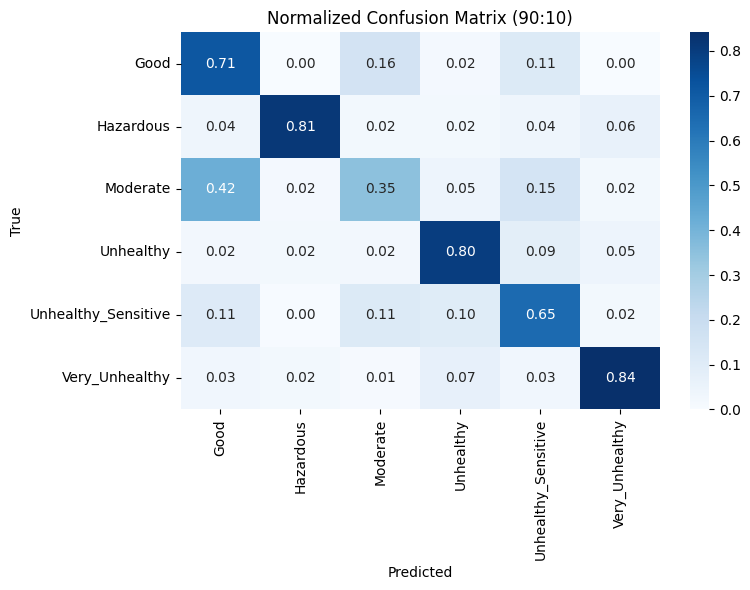

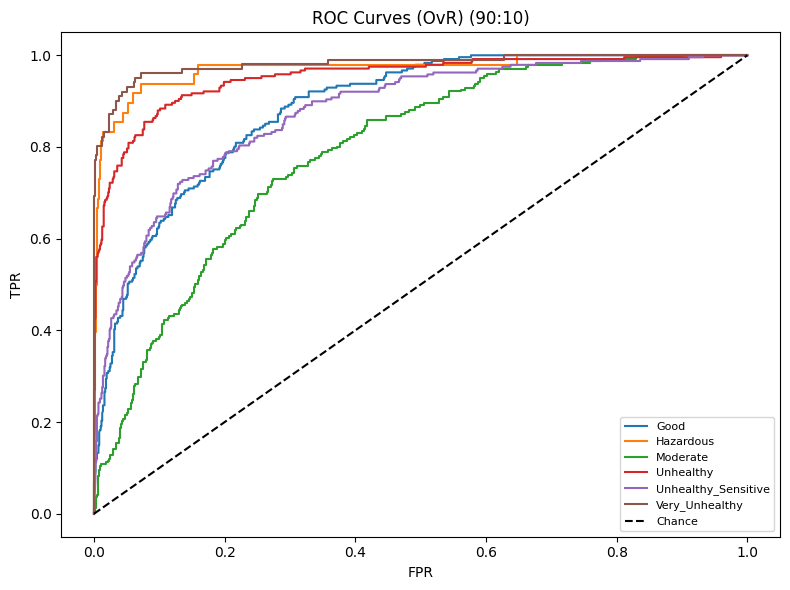


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.42
                Good → Moderate           : 0.16
            Moderate → Unhealthy_Sensitive : 0.15
  Unhealthy_Sensitive → Moderate           : 0.11
                Good → Unhealthy_Sensitive : 0.11

[TEST] Ratio 80:20
Test Loss: 2.421, Test Accuracy: 0.642
Total Test Time: 16.26 seconds for 2221 images
Average Inference Time per Image: 0.007323 s (~7.32 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.636929
1            Hazardous  0.677083
2             Moderate  0.468880
3            Unhealthy  0.754678
4  Unhealthy_Sensitive  0.636743
5       Very_Unhealthy  0.791045

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5512    0.6369    0.5910       482
          Hazardous     0.8228    0.6771    0.7429        96
           Moderate     0.4819    0.4689    0.4753       482
          Unhealthy  

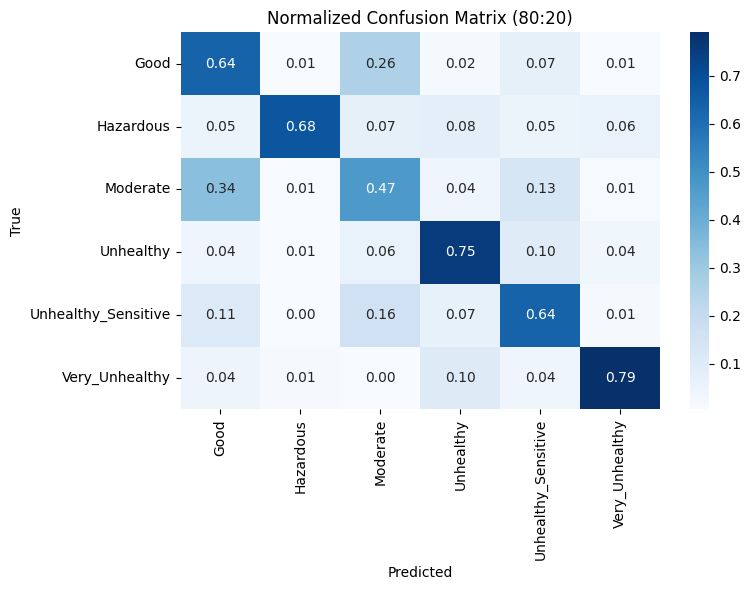

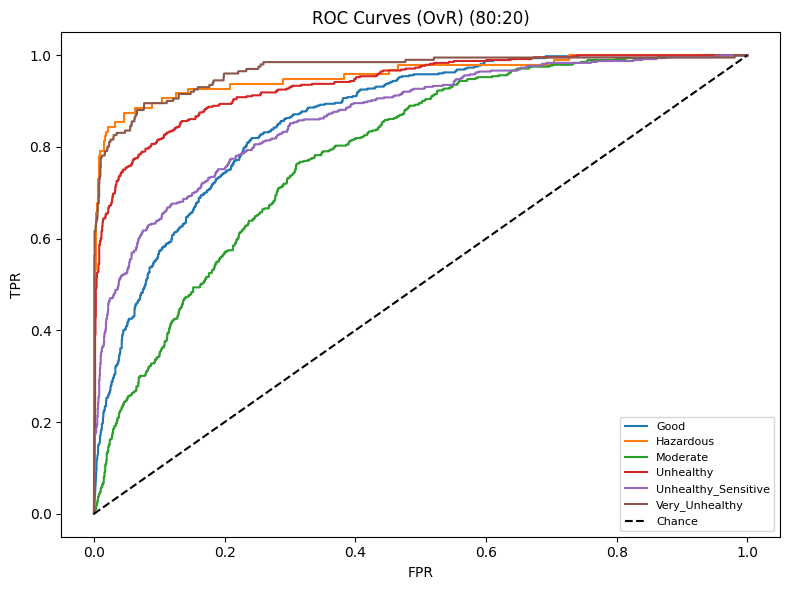


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.34
                Good → Moderate           : 0.26
  Unhealthy_Sensitive → Moderate           : 0.16
            Moderate → Unhealthy_Sensitive : 0.13
  Unhealthy_Sensitive → Good               : 0.11

[TEST] Ratio 70:30
Test Loss: 2.375, Test Accuracy: 0.638
Total Test Time: 23.94 seconds for 3331 images
Average Inference Time per Image: 0.007187 s (~7.19 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.698479
1            Hazardous  0.750000
2             Moderate  0.337950
3            Unhealthy  0.754848
4  Unhealthy_Sensitive  0.689415
5       Very_Unhealthy  0.751656

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5501    0.6985    0.6155       723
          Hazardous     0.7660    0.7500    0.7579       144
           Moderate     0.4900    0.3380    0.4000       722
          Unhealthy  

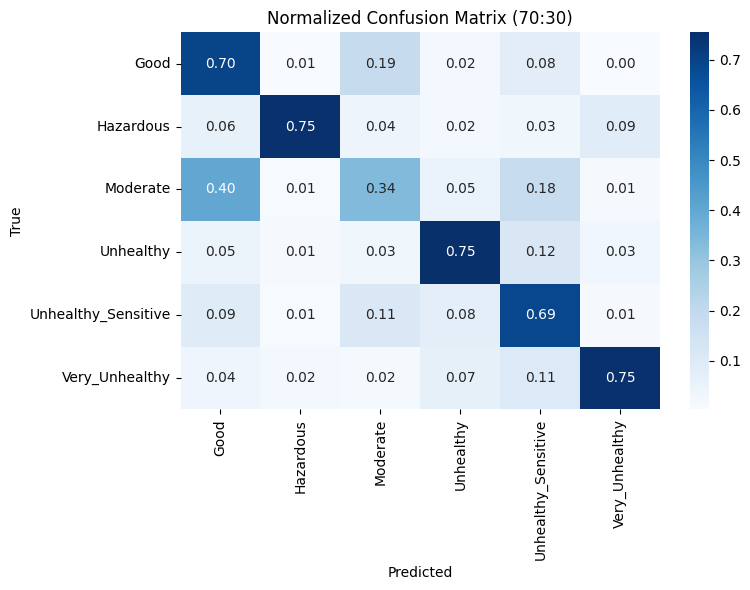

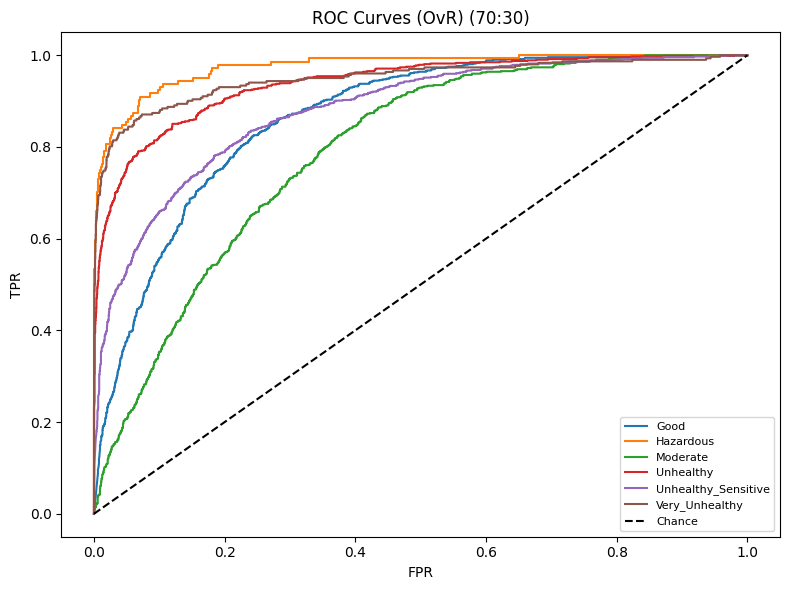


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.40
                Good → Moderate           : 0.19
            Moderate → Unhealthy_Sensitive : 0.18
           Unhealthy → Unhealthy_Sensitive : 0.12
  Unhealthy_Sensitive → Moderate           : 0.11

[TEST] Ratio 60:40
Test Loss: 2.286, Test Accuracy: 0.623
Total Test Time: 32.11 seconds for 4442 images
Average Inference Time per Image: 0.007229 s (~7.23 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.638629
1            Hazardous  0.751295
2             Moderate  0.419522
3            Unhealthy  0.787124
4  Unhealthy_Sensitive  0.578892
5       Very_Unhealthy  0.727047

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5611    0.6386    0.5974       963
          Hazardous     0.7436    0.7513    0.7474       193
           Moderate     0.4649    0.4195    0.4410       963
          Unhealthy  

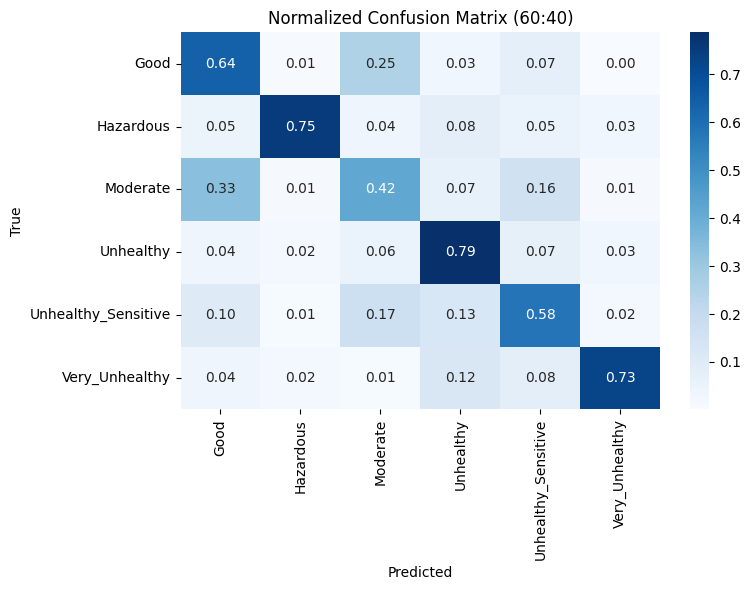

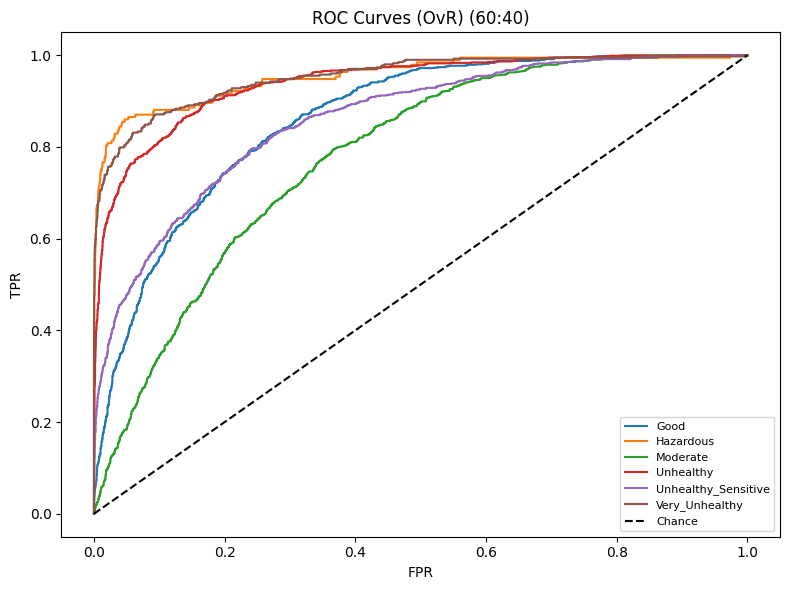


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.33
                Good → Moderate           : 0.25
  Unhealthy_Sensitive → Moderate           : 0.17
            Moderate → Unhealthy_Sensitive : 0.16
  Unhealthy_Sensitive → Unhealthy          : 0.13

[TEST] Ratio 50:50
Test Loss: 2.333, Test Accuracy: 0.599
Total Test Time: 42.53 seconds for 5552 images
Average Inference Time per Image: 0.007661 s (~7.66 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.562292
1            Hazardous  0.712500
2             Moderate  0.431894
3            Unhealthy  0.680233
4  Unhealthy_Sensitive  0.635756
5       Very_Unhealthy  0.755467

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5703    0.5623    0.5663      1204
          Hazardous     0.7277    0.7125    0.7200       240
           Moderate     0.4491    0.4319    0.4403      1204
          Unhealthy  

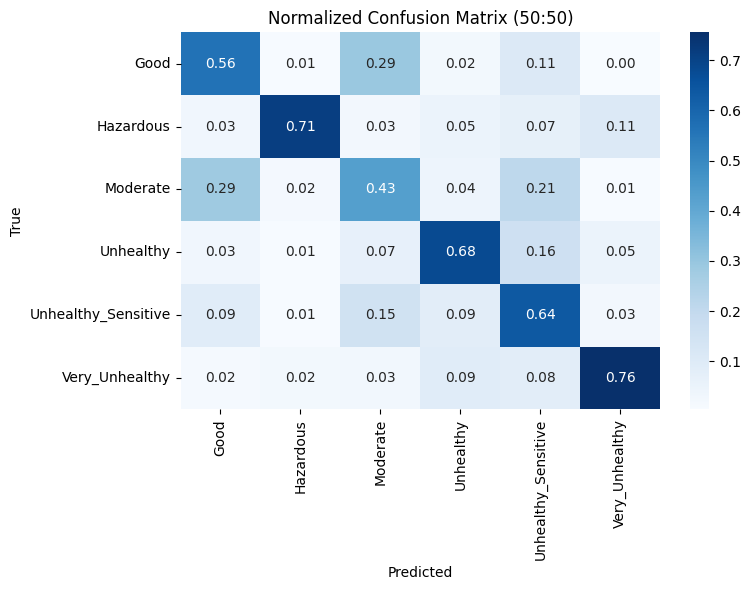

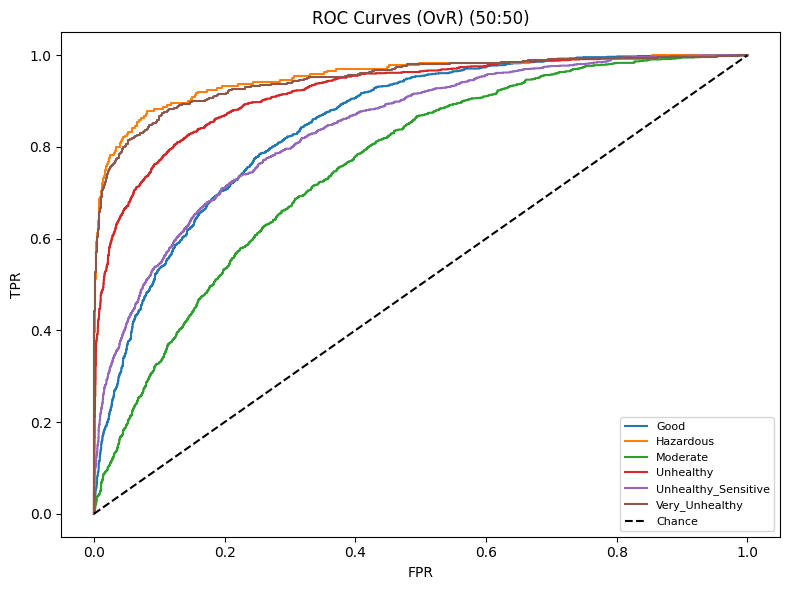


Top Confused Pairs (True → Pred, rate):
                Good → Moderate           : 0.29
            Moderate → Good               : 0.29
            Moderate → Unhealthy_Sensitive : 0.21
           Unhealthy → Unhealthy_Sensitive : 0.16
  Unhealthy_Sensitive → Moderate           : 0.15

[TEST] Ratio 40:60
Test Loss: 2.511, Test Accuracy: 0.589
Total Test Time: 48.30 seconds for 6662 images
Average Inference Time per Image: 0.007251 s (~7.25 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.588927
1            Hazardous  0.768166
2             Moderate  0.410665
3            Unhealthy  0.744460
4  Unhealthy_Sensitive  0.511142
5       Very_Unhealthy  0.738411

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5339    0.5889    0.5601      1445
          Hazardous     0.6852    0.7682    0.7243       289
           Moderate     0.4212    0.4107    0.4158      1444
          Unhealthy  

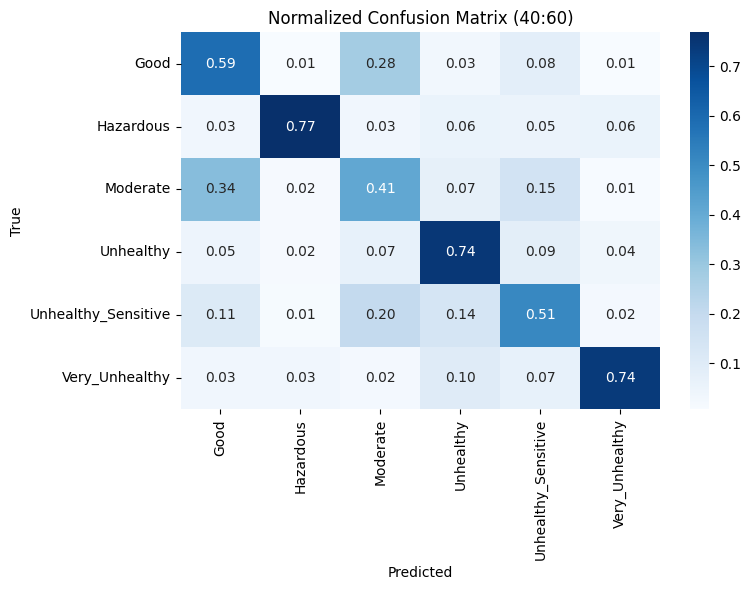

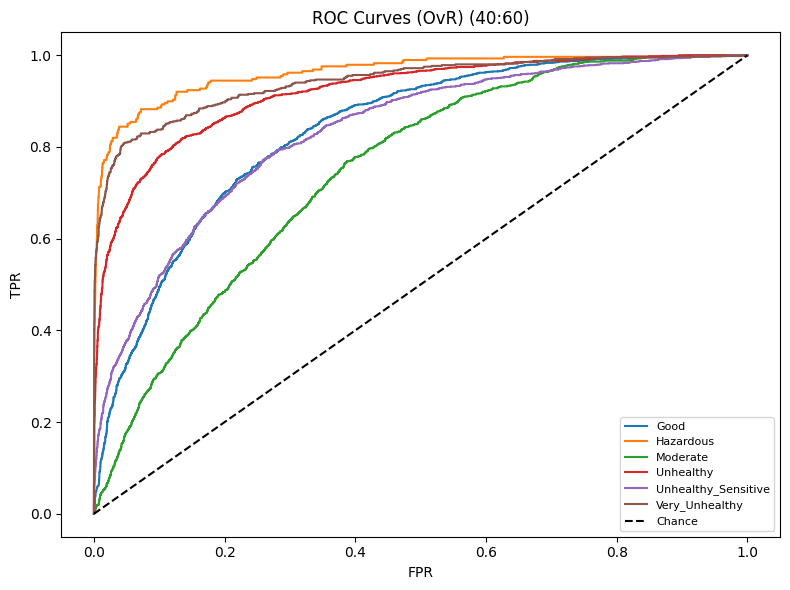


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.34
                Good → Moderate           : 0.28
  Unhealthy_Sensitive → Moderate           : 0.20
            Moderate → Unhealthy_Sensitive : 0.15
  Unhealthy_Sensitive → Unhealthy          : 0.14

[TEST] Ratio 30:70
Test Loss: 2.951, Test Accuracy: 0.556
Total Test Time: 58.44 seconds for 7773 images
Average Inference Time per Image: 0.007518 s (~7.52 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.657177
1            Hazardous  0.614243
2             Moderate  0.266469
3            Unhealthy  0.714540
4  Unhealthy_Sensitive  0.515224
5       Very_Unhealthy  0.696454

Classification Report:

                     precision    recall  f1-score   support

               Good     0.4896    0.6572    0.5612      1686
          Hazardous     0.7393    0.6142    0.6710       337
           Moderate     0.4385    0.2665    0.3315      1685
          Unhealthy  

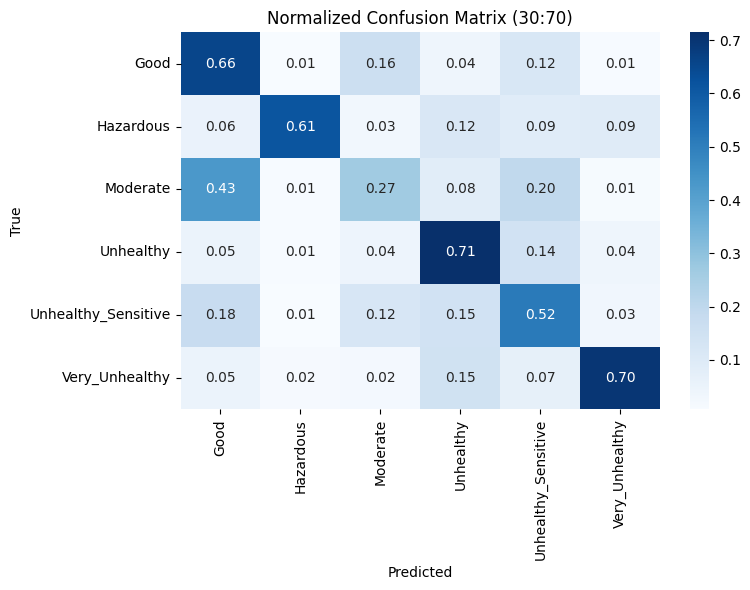

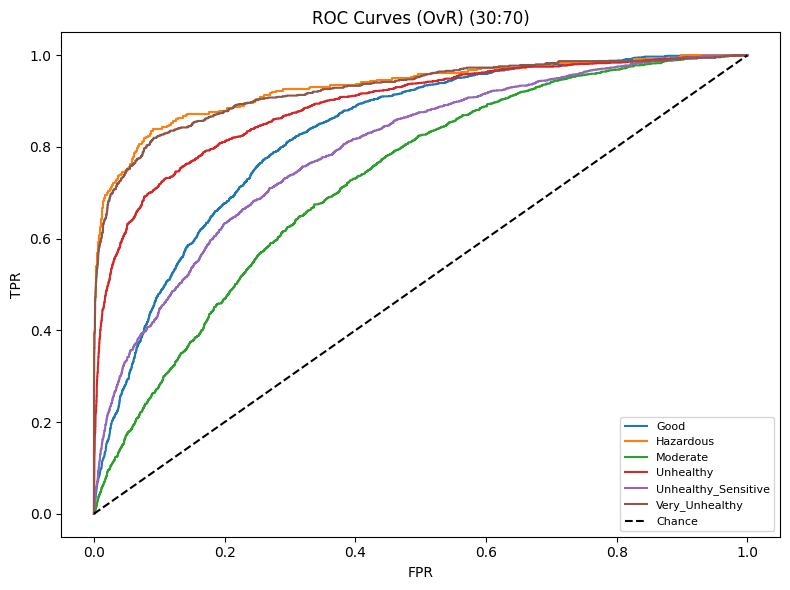


Top Confused Pairs (True → Pred, rate):
            Moderate → Good               : 0.43
            Moderate → Unhealthy_Sensitive : 0.20
  Unhealthy_Sensitive → Good               : 0.18
                Good → Moderate           : 0.16
      Very_Unhealthy → Unhealthy          : 0.15

[TEST] Ratio 20:80
Test Loss: 2.255, Test Accuracy: 0.522
Total Test Time: 64.42 seconds for 8883 images
Average Inference Time per Image: 0.007252 s (~7.25 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.469367
1            Hazardous  0.579221
2             Moderate  0.462617
3            Unhealthy  0.657840
4  Unhealthy_Sensitive  0.425287
5       Very_Unhealthy  0.665012

Classification Report:

                     precision    recall  f1-score   support

               Good     0.5346    0.4694    0.4999      1926
          Hazardous     0.6737    0.5792    0.6229       385
           Moderate     0.3798    0.4626    0.4171      1926
          Unhealthy   

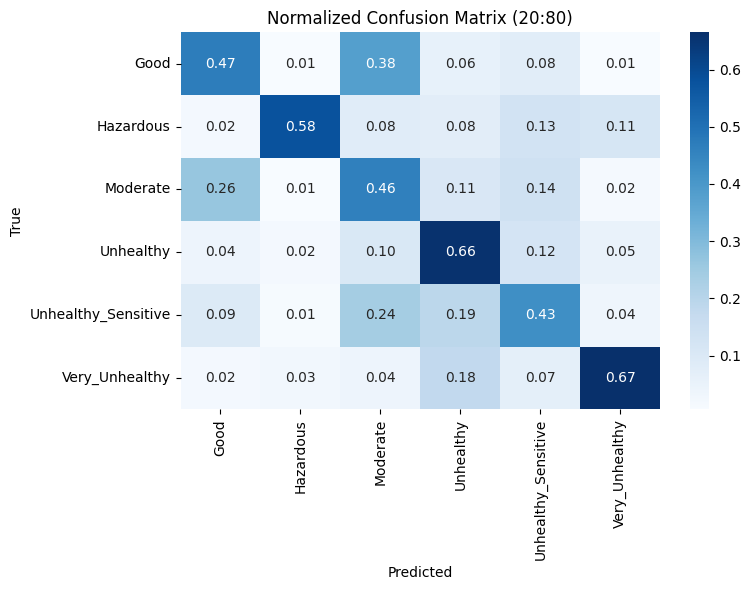

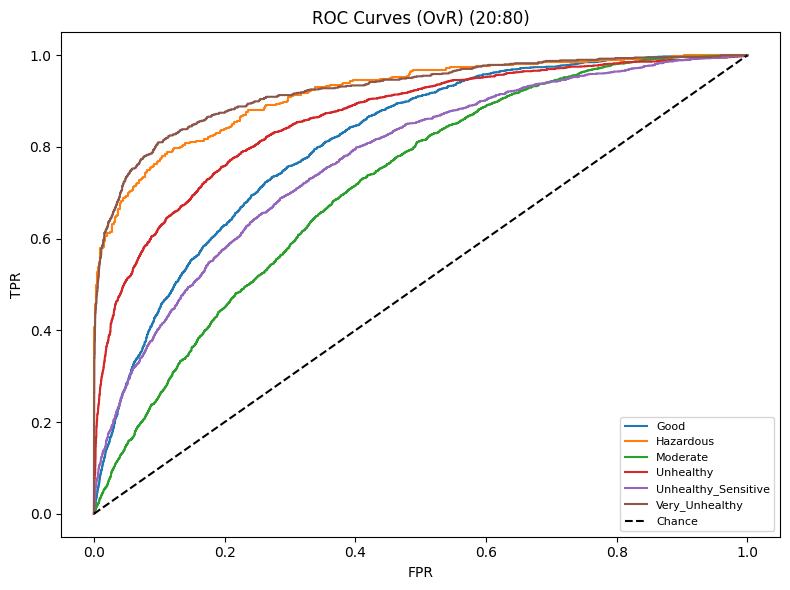


Top Confused Pairs (True → Pred, rate):
                Good → Moderate           : 0.38
            Moderate → Good               : 0.26
  Unhealthy_Sensitive → Moderate           : 0.24
  Unhealthy_Sensitive → Unhealthy          : 0.19
      Very_Unhealthy → Unhealthy          : 0.18

[TEST] Ratio 10:90
Test Loss: 1.616, Test Accuracy: 0.462
Total Test Time: 73.35 seconds for 9993 images
Average Inference Time per Image: 0.007340 s (~7.34 ms/image)

Per-Class Accuracy:
                 Class  Accuracy
0                 Good  0.444393
1            Hazardous  0.376443
2             Moderate  0.377942
3            Unhealthy  0.643583
4  Unhealthy_Sensitive  0.399257
5       Very_Unhealthy  0.459161

Classification Report:

                     precision    recall  f1-score   support

               Good     0.4770    0.4444    0.4601      2167
          Hazardous     0.7477    0.3764    0.5008       433
           Moderate     0.3589    0.3779    0.3682      2167
          Unhealthy   

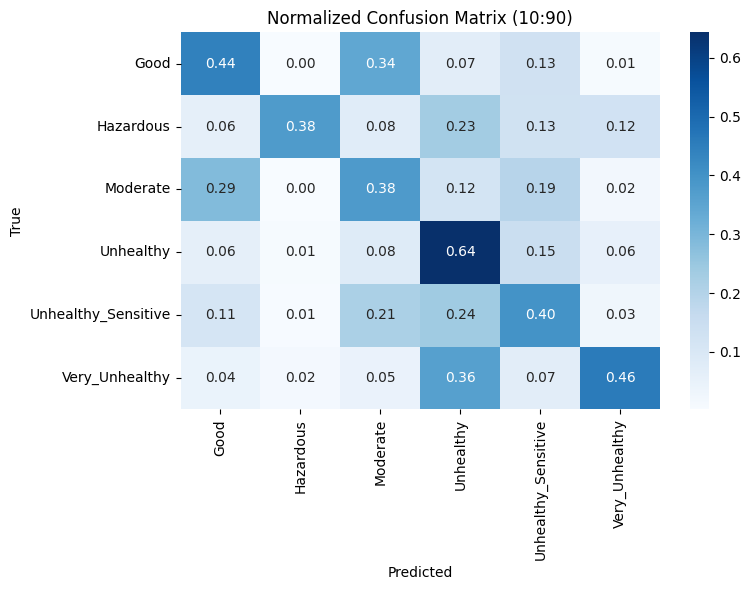

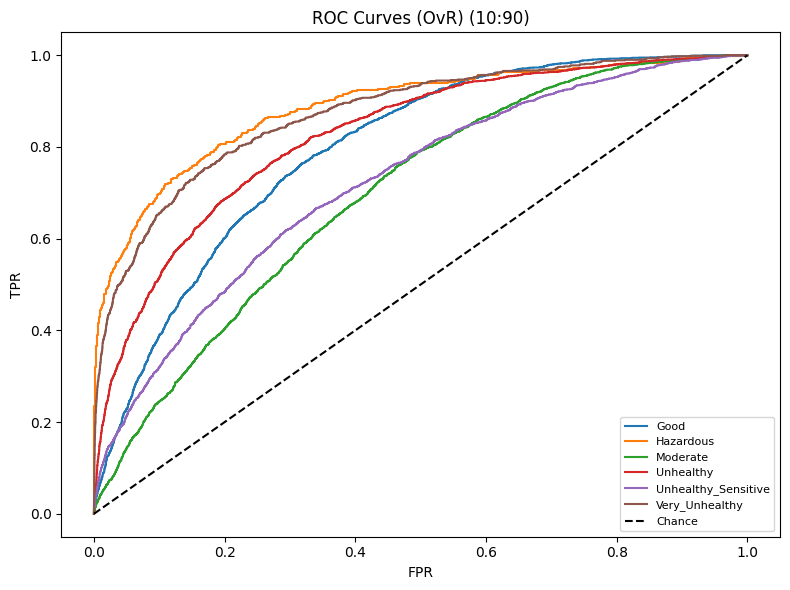


Top Confused Pairs (True → Pred, rate):
      Very_Unhealthy → Unhealthy          : 0.36
                Good → Moderate           : 0.34
            Moderate → Good               : 0.29
  Unhealthy_Sensitive → Unhealthy          : 0.24
           Hazardous → Unhealthy          : 0.23


In [22]:
import time
import os
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

CLASS_NAMES = sorted(df['label'].unique())
CLASS_TO_ID = {c:i for i, c in enumerate(CLASS_NAMES)}

for (tr, te) in RATIOS:
    print(f"\n[TEST] Ratio {tr}:{te}")
    save_path_checkpoints = os.path.join("/kaggle/working/task2_mobilenetv3", f"{tr}_{te}")
    best_checkpoint_path = f"{save_path_checkpoints}/model.pt"

    # MobileNetV3-Large model for testing
    try:
        from torchvision.models import MobileNet_V3_Large_Weights
        model = models.mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1).to(device)
    except Exception:
        model = models.mobilenet_v3_large(pretrained=True).to(device)

    num_ftrs = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(num_ftrs, len(CLASS_NAMES))
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    criterion = nn.CrossEntropyLoss()

    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_weight"])

    split = SPLITS[(tr, te)]
    _, _, dataloader_test_dataset = data_transform(split["train_df"], split["valid_df"], split["test_df"])

    start_time = time.time()
    test_loss, test_accuracy, all_preds, all_labels, all_probs = evaluate_model(
        model, criterion, dataloader_test_dataset, return_preds=True
    )
    end_time = time.time()
    test_time = end_time - start_time

    n_test_images = len(split["test_df"])
    avg_inf_per_image_sec = test_time / n_test_images if n_test_images > 0 else float('nan')
    avg_inf_per_image_ms = avg_inf_per_image_sec * 1000.0

    print(f"Test Loss: {test_loss:.3f}, Test Accuracy: {test_accuracy:.3f}")
    print(f"Total Test Time: {test_time:.2f} seconds for {n_test_images} images")
    print(f"Average Inference Time per Image: {avg_inf_per_image_sec:.6f} s (~{avg_inf_per_image_ms:.2f} ms/image)")

    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    per_class_acc_df = pd.DataFrame({'Class': CLASS_NAMES, 'Accuracy': per_class_acc})
    print("\nPer-Class Accuracy:")
    print(per_class_acc_df)

    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
    print("\nClassification Report:\n")
    print(report)

    try:
        y_true_bin = label_binarize(all_labels, classes=np.arange(len(CLASS_NAMES)))
        macro_auc = roc_auc_score(y_true_bin, all_probs, average='macro', multi_class='ovr')
    except Exception:
        macro_auc = np.nan
    print(f"Macro ROC–AUC (OvR): {macro_auc if not np.isnan(macro_auc) else 'NA'}")

    plt.figure(figsize=(8,6))
    import seaborn as sns
    sns.heatmap(cm_norm, annot=True, fmt=".2f", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Normalized Confusion Matrix ({tr}:{te})')
    cm_path = os.path.join(save_path_checkpoints, f'cm_norm_{tr}-{te}.png')
    plt.tight_layout()
    plt.savefig(cm_path)
    plt.show()

    try:
        plt.figure(figsize=(8,6))
        for i, cname in enumerate(CLASS_NAMES):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
            plt.plot(fpr, tpr, label=cname)
        plt.plot([0,1],[0,1],'k--',label='Chance')
        plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'ROC Curves (OvR) ({tr}:{te})'); plt.legend(fontsize=8)
        roc_path = os.path.join(save_path_checkpoints, f'roc_{tr}-{te}.png')
        plt.tight_layout(); plt.savefig(roc_path); plt.show()
    except Exception:
        pass

    cm_norm_off = cm_norm.copy()
    np.fill_diagonal(cm_norm_off, 0.0)

    confused = []
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            if i == j:
                continue
            confused.append((CLASS_NAMES[i], CLASS_NAMES[j], cm_norm_off[i, j]))
    confused.sort(key=lambda x: x[2], reverse=True)
    top_k = [c for c in confused if np.isfinite(c[2]) and c[2] > 0][:5]
    if top_k:
        print("\nTop Confused Pairs (True → Pred, rate):")
        for (t, p, r) in top_k:
            print(f"  {t:>18s} → {p:<18s} : {r:.2f}")
    else:
        print("\nNo significant confused pairs detected.")
